In [1]:
'''
more complex architecture 
similar to wavenet (except char level)
starter code similart to part 3
'''

'\nmore complex architecture \nsimilar to wavenet (except char level)\nstarter code similart to part 3\n'

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [3]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [6]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [7]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


In [8]:
# Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5  # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
      self.eps = eps
      self.momentum = momentum
      self.training = True

      # parameters (trained with backprop)
      self.gamma = torch.ones(dim)
      self.beta = torch.zeros(dim)

      # buffers (trained with a running 'momentum update')
      self.running_mean = torch.zeros(dim)
      self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      # departure from torch API
      # we assume C is last dim and torch assumes it's the second dim
      # We assume N,L,C and torch does N,C,L
      if x.ndim == 2: dim = 0
      elif x.ndim == 3: dim = (0, 1)
      xmean = x.mean(dim, keepdim=True)  # batch mean
      xvar = x.var(dim, keepdim=True)  # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps)  # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    
    # update the buffers
    if self.training:
      with torch.no_grad():
          self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
          self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------

class Tanh:

  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------

class Embedding:
  def __init__(self, num_emb, emb_dim):
    self.weight = torch.randn((num_emb, emb_dim))

  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]

# -----------------------------------------------------------------------------------------------
class Flatten:
  def __call__(self, x):
    self.out = x.view(x.shape[0], -1)
    return self.out

  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
# departure from torch API
class FlattenConsecutive: # (5)

  def __init__(self, n):
    self.n = n # how much do we want to flatten by?
  
  def __call__(self, x):
    B, T, C = x.shape # Batch, Time (aka tokens), C=embedding
    # lecture impl does this explicitly
    # x.view(B, T//self.n, C*self.n) 
    # we pass -1 and let torch infer the second dim
    # lec says better to be explicit so we get errors if we mess something up
    x = x.view(B, -1, C * self.n) 
    if x.shape[1] == 1:
      # convert B, 1, C -> B, C
      # eg if we convert 4, 8, 10 into 4, 1, 80 (n = 8) then we can get rid of the useless dimension
      x = x.squeeze(1) 
    self.out = x
    return self.out

  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Sequential:
  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]



In [9]:
torch.manual_seed(42); # seed rng for reproducibility

In [10]:
n_embd = 10  # the dimensionality of the character embedding vectors
n_hidden = 68  # the number of neurons in the hidden layer of the MLP
# (5): Setting n_hidden to 68 so that we preserve the num params with the bigger network
# we can see if the same num params are more efficient

model = Sequential([
  Embedding(vocab_size, n_embd),
  
  FlattenConsecutive(2),
  Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  
  FlattenConsecutive(2),
  Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  
  FlattenConsecutive(2),
  Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1  # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
  p.requires_grad = True



22397


In [195]:
# :::(5):::
ix = torch.randint(0, Xtr.shape[0], (4,)) # pick 4 random examples
Xb, Yb = Xtr[ix], Ytr[ix]
print(Xb.shape) # 4,8 --- 4 examples, each with 8 (block size) "tokens"

print('----')
logits = model(Xb)
print(model.layers[0].out.shape) # 4,8,10 -- 10 dim embedding for each 4x8 above
print(model.layers[1].out.shape) # 4,80  -- embcat prev aka torch.view. embedding put into 1 row
print(model.layers[2].out.shape) # 4, 200 -- 4 inputs, n_hidden(200) outputs

print('----')
# same example spelled out with rand numbers to viz shapes
print(((torch.randn(4, 80) @ torch.randn(80, 200)) + torch.randn(200)).shape ) # same 4,200 as above just spelled out
# torch can do more powerful mat muls. eg adding a new dim
print(((torch.randn(4, 5, 80) @ torch.randn(80, 200)) + torch.randn(200)).shape ) # same 4,5,200 since input is 4,5,80
print(((torch.randn(4, 10, 10, 5, 80) @ torch.randn(80, 200)) + torch.randn(200)).shape ) # even more dims

# mat mul works on the last dim of the LHS and the other input dims are left unchanged. They are just "batch dimensions"
# we can use this in our network. We don't have to flatten completely in the first step
# Instead of (1, 2, 3, 4, 5, 6, 7, 8)
# we can do (1, 2), (3, 4), (5, 6), (7, 8)

print('----')
# instead of processing 8 chars at once, we process 2 so the second param is 20, 200 in shape and first is 4, 4, 20 
# 4, 4, 20 is just a diff view on 4,80 essentially
print(((torch.randn(4, 4, 20) @ torch.randn(20, 200)) + torch.randn(200)).shape ) # 4, 4, 80

print('----')
# we need to change flatten layer to output 4, 4, 20 instead of 4, 80
# i.e. it doesn't fully flatten
# how do we implement that?
e = torch.randn(4, 8, 10)
print(e.view(4, -1).shape) # 4, 80
# in python you can do this
print(list(range(10))[::2]) # gets all even elements
print(list(range(10))[1::2]) # gets all odd elements
print(e[:, ::2, :].shape) # even chars
print(e[:, 1::2, :].shape) # odd chars
# concat even and odd chars
explicit = torch.cat([e[:, ::2, :], e[:, 1::2, :]], dim=2)
print(explicit.shape) # 4, 4, 20 <--- desired shape

print('----')
# ^ obviously torch has nicer ways to do this
implicit = e.view(4, 4, 20)
print(implicit.shape)
print((implicit == explicit).all()) # They are the same


torch.Size([4, 8])
----
torch.Size([4, 8, 10])
torch.Size([4, 4, 20])
torch.Size([4, 4, 68])
----
torch.Size([4, 200])
torch.Size([4, 5, 200])
torch.Size([4, 10, 10, 5, 200])
----
torch.Size([4, 4, 200])
----
torch.Size([4, 80])
[0, 2, 4, 6, 8]
[1, 3, 5, 7, 9]
torch.Size([4, 4, 10])
torch.Size([4, 4, 10])
torch.Size([4, 4, 20])
----
torch.Size([4, 4, 20])
tensor(True)


In [197]:
# :::(5) cont'd
# viz shapes of model outs
for layer in model.layers:
  print(layer.__class__.__name__, ":", tuple(layer.out.shape))

AttributeError: 'Embedding' object has no attribute 'out'

In [11]:
# FWD PASS
'''
:::(2):::
this code is kinda ugly
embedding table "C" is special-cased outside of our list of layers

::: (3) :::
Putting the layers in an array is kinda ugly
We can use/reimplement torch.nn.Sequential
'''
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y

  # forward pass
  logits = model(Xb) # (3)
  loss = F.cross_entropy(logits, Yb)  # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01  # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0:  # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  # break



      0/ 200000: 3.3142
  10000/ 200000: 2.2096
  20000/ 200000: 2.1495
  30000/ 200000: 2.1232
  40000/ 200000: 1.9629
  50000/ 200000: 2.4183
  60000/ 200000: 1.9633
  70000/ 200000: 1.8960
  80000/ 200000: 2.1884
  90000/ 200000: 1.8161
 100000/ 200000: 1.5931
 110000/ 200000: 2.3607
 120000/ 200000: 2.3670
 130000/ 200000: 1.9098
 140000/ 200000: 2.2285
 150000/ 200000: 1.7118
 160000/ 200000: 1.8517
 170000/ 200000: 1.9997
 180000/ 200000: 2.1043
 190000/ 200000: 1.6969


In [ ]:
# old loss plot
plt.plot(lossi)

tensor([[0, 1],
        [2, 3],
        [4, 5],
        [6, 7],
        [8, 9]])
torch.Size([200, 1000])


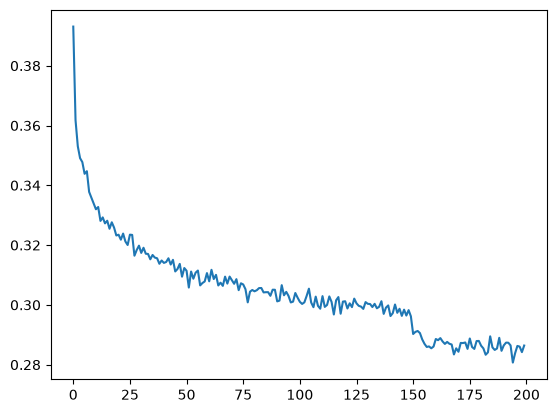

In [12]:
'''
:::(1):::
average up some of lossi to make the graph more representative
'''
print(torch.arange(10).view(-1, 2))
print(torch.tensor(lossi).view(-1, 1000).shape)
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [13]:
# put batchnorm layers in eval mode
for layer in model.layers:
  layer.training = False

In [14]:
# evaluate the loss
@torch.no_grad()  # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x, y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]


  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')


train 1.9110119342803955
val 2.0201919078826904


In [185]:
# sample from the model

for _ in range(20):

  out = []
  context = [0] * block_size  # initialize with all ...

  while True:
    logits = model(torch.tensor([context]))
    probs = F.softmax(logits, dim=1)

    # sample from the distribution
    ix = torch.multinomial(probs, num_samples=1).item()

    # shift the context window and track the samples
    context = context[1:] + [ix]
    out.append(ix)

    # if we sample the special '.' token, break
    if ix == 0:
      break

  print(''.join(itos[i] for i in out))  # decode and print the generated word


nyaeh.
kyliana.
tayotair.
benker.
elmako.
saahim.
martin.
dani.
autevison.
henny.
marmelii.
ghalani.
loontae.
catalo.
damariou.
scarly.
paxcegen.
azaleia.
pugtorre.
menavie.


```
## :::(4):::
we can make this model much bigger
we only have a single hidden layer but adding new layers might not be productive
  we crush all the chars into a single layer at the beginning
  silly to squash all that info so fast in a single step
want it to look more like fig 3 in WaveNet paper: https://arxiv.org/pdf/1609.03499
the input chars are not "crushed" in a single layer

they are crushed in multiple layers
  we take 2 chars and make it bigram
  then fuse 2 bigrams into 4 char thing
  etc

we change block_size to 8 for this
```

## performance log

#### with block size = 3 (basically same as makemore 3)

```
train 2.0583250522613525
val 2.1065292358398438
```

#### block size = 8 before wavenet

```
train 1.9163438081741333
val 2.034247636795044
```

#### Initial wavenet like impl (with batchnorm bug)
```
train 1.9399470090866089
val 2.0249998569488525
```

#### Initial wavenet like impl (w/o batchnorm bug)
```
train 1.9110119342803955
val 2.0201919078826904
```
Small improvement due to batchnorm bugfix



```
(5) cont'd 
the loss for the wavenet like impl above is similar to the old one
but we can do a lot more in terms of turning hyperparameters
also our network is pretty naiive right now
we also may have a bug in BatchNorm1d

::: (6) ::: Fixing BatchNorm1d

it assumes the tensor is 2d but now we pass it 3D
the reason it works is bc of broadcasting rules but it's a bug
see ~min 40 in video

```